# ISLES 2022/2026 Dataset Analysis
This notebook performs analysis on the Ischemic Stroke Lesion Segmentation dataset hosted on Google Drive.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Setup and Imports
We will use common medical imaging libraries like `nibabel` and `SimpleITK` for NIfTI files.

In [2]:
!pip install nibabel simpleitk monai

import os
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 58.0 MB/s eta 0:00:00


## Data Loading
Please ensure the file ID from your link matches the path below after mounting.

Found 1000 NIfTI files.
 - derivatives/sub-strokecase0001/ses-0001/sub-strokecase0001_ses-0001_msk.nii.gz
 - derivatives/sub-strokecase0002/ses-0001/sub-strokecase0002_ses-0001_msk.nii.gz
 - derivatives/sub-strokecase0003/ses-0001/sub-strokecase0003_ses-0001_msk.nii.gz
 - derivatives/sub-strokecase0004/ses-0001/sub-strokecase0004_ses-0001_msk.nii.gz
 - derivatives/sub-strokecase0005/ses-0001/sub-strokecase0005_ses-0001_msk.nii.gz

Analyzing file: sub-strokecase0001_ses-0001_msk.nii.gz
Shape of volume: (112, 112, 73)


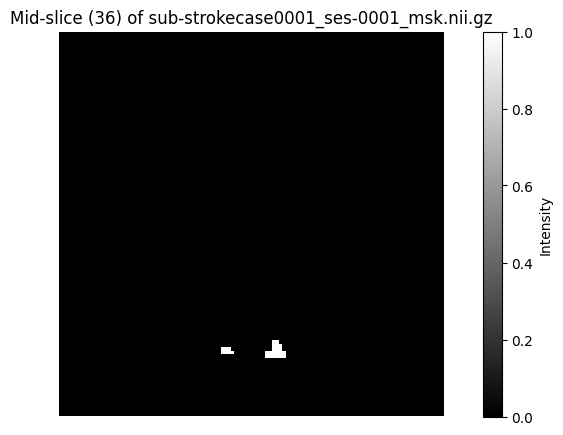

In [7]:
import glob
import os
import nibabel as nib
import matplotlib.pyplot as plt

# Correct path based on the directory listing
data_root = '/content/drive/MyDrive/ISLES-2022/ISLES-2022'

# Find all NIfTI files in the dataset
nifti_files = sorted(glob.glob(os.path.join(data_root, '**/*.nii.gz'), recursive=True))

if nifti_files:
    print(f"Found {len(nifti_files)} NIfTI files.")

    # Display some file paths for verification
    for f in nifti_files[:5]:
        print(f" - {os.path.relpath(f, data_root)}")

    # Example analysis: Load and visualize the first image
    sample_img = nib.load(nifti_files[0])
    data = sample_img.get_fdata()
    print(f"\nAnalyzing file: {os.path.basename(nifti_files[0])}")
    print(f"Shape of volume: {data.shape}")

    # Visualization of the middle slice
    mid_slice = data.shape[2] // 2
    plt.figure(figsize=(10, 5))
    plt.imshow(data[:, :, mid_slice].T, cmap='gray', origin='lower')
    plt.title(f"Mid-slice ({mid_slice}) of {os.path.basename(nifti_files[0])}")
    plt.colorbar(label='Intensity')
    plt.axis('off')
    plt.show()
else:
    print(f"No NIfTI files found in {data_root}. Please check the folder structure again.")

## Dataset Organization
We will now organize the files into images and masks for structured analysis.

Total Raw Images Found: 750
Total Masks Found: 250
Image shape: (281, 352, 352), Mask shape: (112, 112, 73)


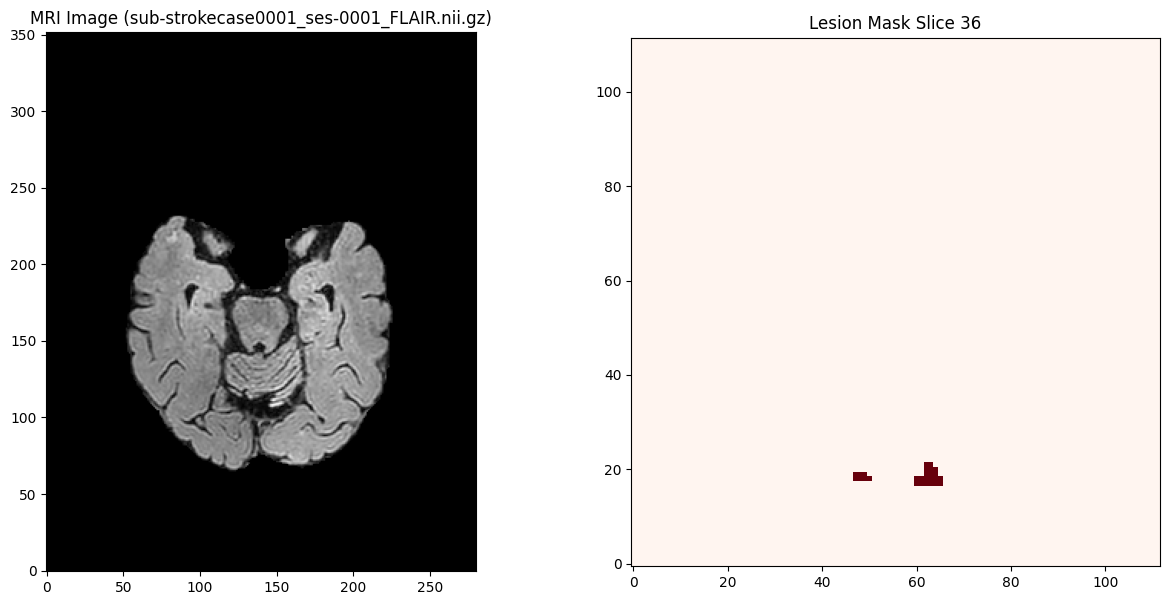

In [11]:
import glob
import os
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np

# Broaden search to find images and masks within the ISLES directory
all_nifti = glob.glob(os.path.join(data_root, '**/*.nii.gz'), recursive=True)

# Separate masks from raw images
masks = sorted([f for f in all_nifti if '_msk' in f])
raw_images = sorted([f for f in all_nifti if '_msk' not in f])

print(f"Total Raw Images Found: {len(raw_images)}")
print(f"Total Masks Found: {len(masks)}")

if len(raw_images) > 0 and len(masks) > 0:
    img_path = raw_images[0]
    base_name = os.path.basename(img_path).split('_')[0]
    matching_masks = [m for m in masks if base_name in m]

    if matching_masks:
        msk_path = matching_masks[0]
        img_nib = nib.load(img_path)
        msk_nib = nib.load(msk_path)

        img_vol = img_nib.get_fdata()
        msk_vol = msk_nib.get_fdata()

        print(f"Image shape: {img_vol.shape}, Mask shape: {msk_vol.shape}")

        # Use separate slice indices for each to avoid IndexError
        img_slice_idx = img_vol.shape[2] // 2
        # Map the slice index proportionally if shapes differ significantly
        msk_slice_idx = int(img_slice_idx * (msk_vol.shape[2] / img_vol.shape[2]))

        fig, axes = plt.subplots(1, 2, figsize=(15, 7))

        axes[0].imshow(img_vol[:, :, img_slice_idx].T, cmap='gray', origin='lower')
        axes[0].set_title(f'MRI Image ({os.path.basename(img_path)})')

        # For the overlay, we show the mask slice corresponding to the brain area
        axes[1].imshow(msk_vol[:, :, msk_slice_idx].T, cmap='Reds', origin='lower')
        axes[1].set_title(f'Lesion Mask Slice {msk_slice_idx}')

        plt.show()
    else:
        print('Found images and masks but could not match a pair.')
else:
    print('Dataset structure still not fully recognized.')

## Lesion Statistics
Calculating the volume of lesions across the dataset.

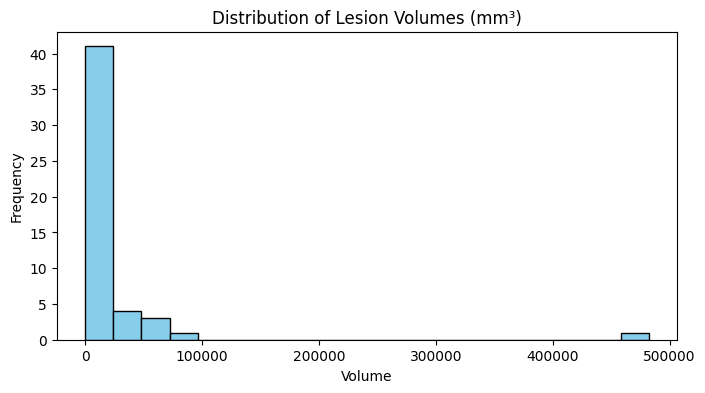

In [9]:
lesion_volumes = []
for m_path in masks[:50]: # Analyzing first 50 for speed
    m_img = nib.load(m_path)
    m_data = m_img.get_fdata()
    # Calculate volume (voxel count * voxel dimensions)
    voxel_dims = m_img.header.get_zooms()
    volume = np.sum(m_data) * np.prod(voxel_dims)
    lesion_volumes.append(volume)

plt.figure(figsize=(8, 4))
plt.hist(lesion_volumes, bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Lesion Volumes (mm³)')
plt.xlabel('Volume')
plt.ylabel('Frequency')
plt.show()